In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Dataset.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


INSPECTING DATA



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [7]:
df["TotalCharges"] = df["TotalCharges"].replace(" ",0)
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.isnull().sum() #column wise
df.isnull().sum().sum() #overall null

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [17]:
df.duplicated().sum() #overall
df["customerID"].duplicated().sum() #based on customer id

np.int64(0)

convert 0 and 1 val of senior citizen to yes or no

In [40]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)     
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


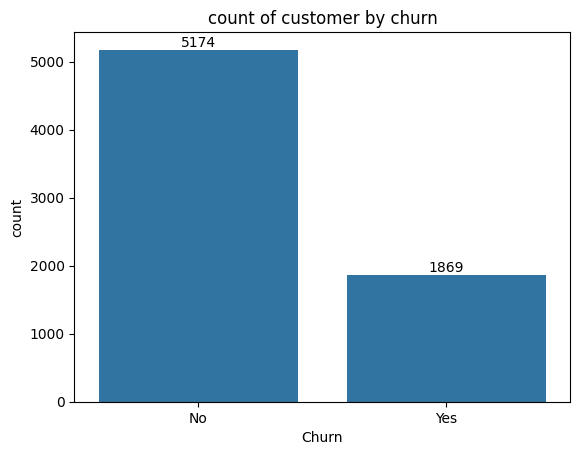

In [23]:
ax = sns.countplot(x = 'Churn' , data = df)
ax.bar_label(ax.containers[0])
plt.title("count of customer by churn")
plt.show()

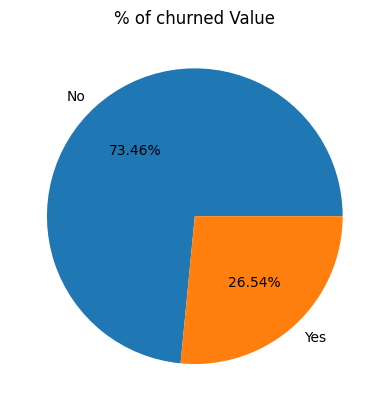

In [25]:
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%4.2f%%") 
plt.title("% of churned Value")
plt.show()


lets explore the reason behind Churning

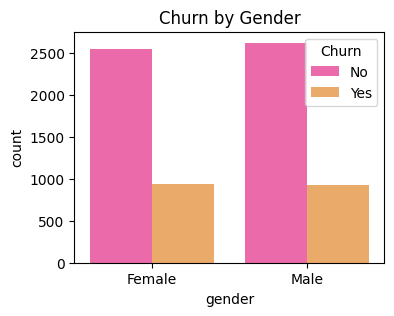

In [37]:
plt.figure(figsize = (4,3))
sns.countplot(x = "gender", data = df, hue = "Churn",palette = "spring")
plt.title("Churn by Gender")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_24404\648607159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = "SeniorCitizen", data = df,palette = "spring")


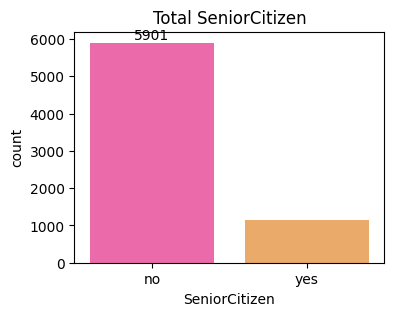

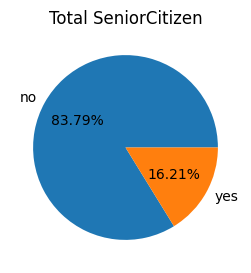

In [52]:
plt.figure(figsize = (4,3))
ax = sns.countplot(x = "SeniorCitizen", data = df,palette = "spring")
ax.bar_label(ax.containers[0])
plt.title("Total SeniorCitizen")
plt.show()

import matplotlib.pyplot as plt

# Step 1: Count values of SeniorCitizen
counts = df["SeniorCitizen"].value_counts()  # returns a Series

# Step 2: Plot pie chart
plt.figure(figsize=(4,3))
plt.pie(
    counts,                              # sizes of slices
    labels=counts.index,                 # category labels (0, 1)
    autopct="%1.2f%%",                    # display percentages
)

# Step 3: Title and show
plt.title("Total SeniorCitizen")
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_24404\1897086772.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(idx, bottom_vals[idx] + val / 2, f"{val:.1f}%", ha="center", va="center", fontsize=8)


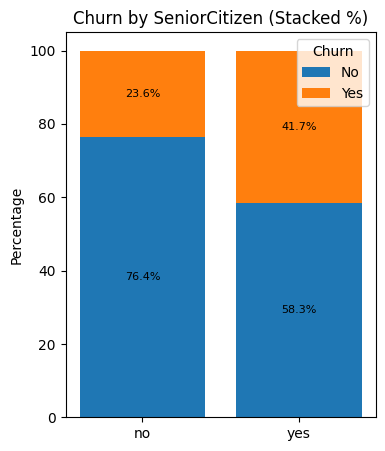

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Prepare the percentage data
counts = df.groupby(["SeniorCitizen", "Churn"]).size().reset_index(name="count")

# Pivot so 'Churn' categories become columns
pivot_df = counts.pivot(index="SeniorCitizen", columns="Churn", values="count").fillna(0)

# Calculate percentages
percent_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# Step 2: Plot stacked bar
fig, ax = plt.subplots(figsize=(4, 3))

bottom_vals = None
for churn_value in percent_df.columns:
    ax.bar(
        percent_df.index, 
        percent_df[churn_value], 
        label=churn_value, 
        bottom=bottom_vals
    )
    bottom_vals = percent_df[churn_value] if bottom_vals is None else bottom_vals + percent_df[churn_value]

# Step 3: Add percentage labels
bottom_vals = [0] * len(percent_df)
for churn_value in percent_df.columns:
    for idx, val in enumerate(percent_df[churn_value]):
        ax.text(idx, bottom_vals[idx] + val / 2, f"{val:.1f}%", ha="center", va="center", fontsize=8)
    bottom_vals = bottom_vals + percent_df[churn_value]

# Step 4: Formatting
ax.set_title("Churn by SeniorCitizen (Stacked %)")
ax.set_ylabel("Percentage")
ax.legend(title="Churn")

plt.show()


comparatively a greater percentage of people in senior citizen category have churned

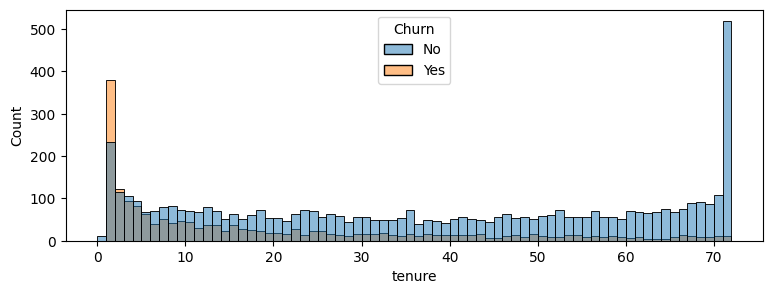

In [59]:
plt.figure(figsize = (9,3))
sns.histplot(x = "tenure", data = df,bins = 72, hue = "Churn")
plt.show()

people who have used our service for long time have stayed and people
who have used our services for 1 or 2 months have churned

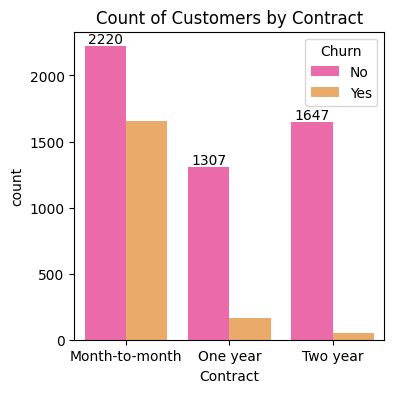

In [62]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract", data = df,palette = "spring",hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()


people with month to month contract are likely to churn
than from those who have 1 to 2 years of Contracts

In [4]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

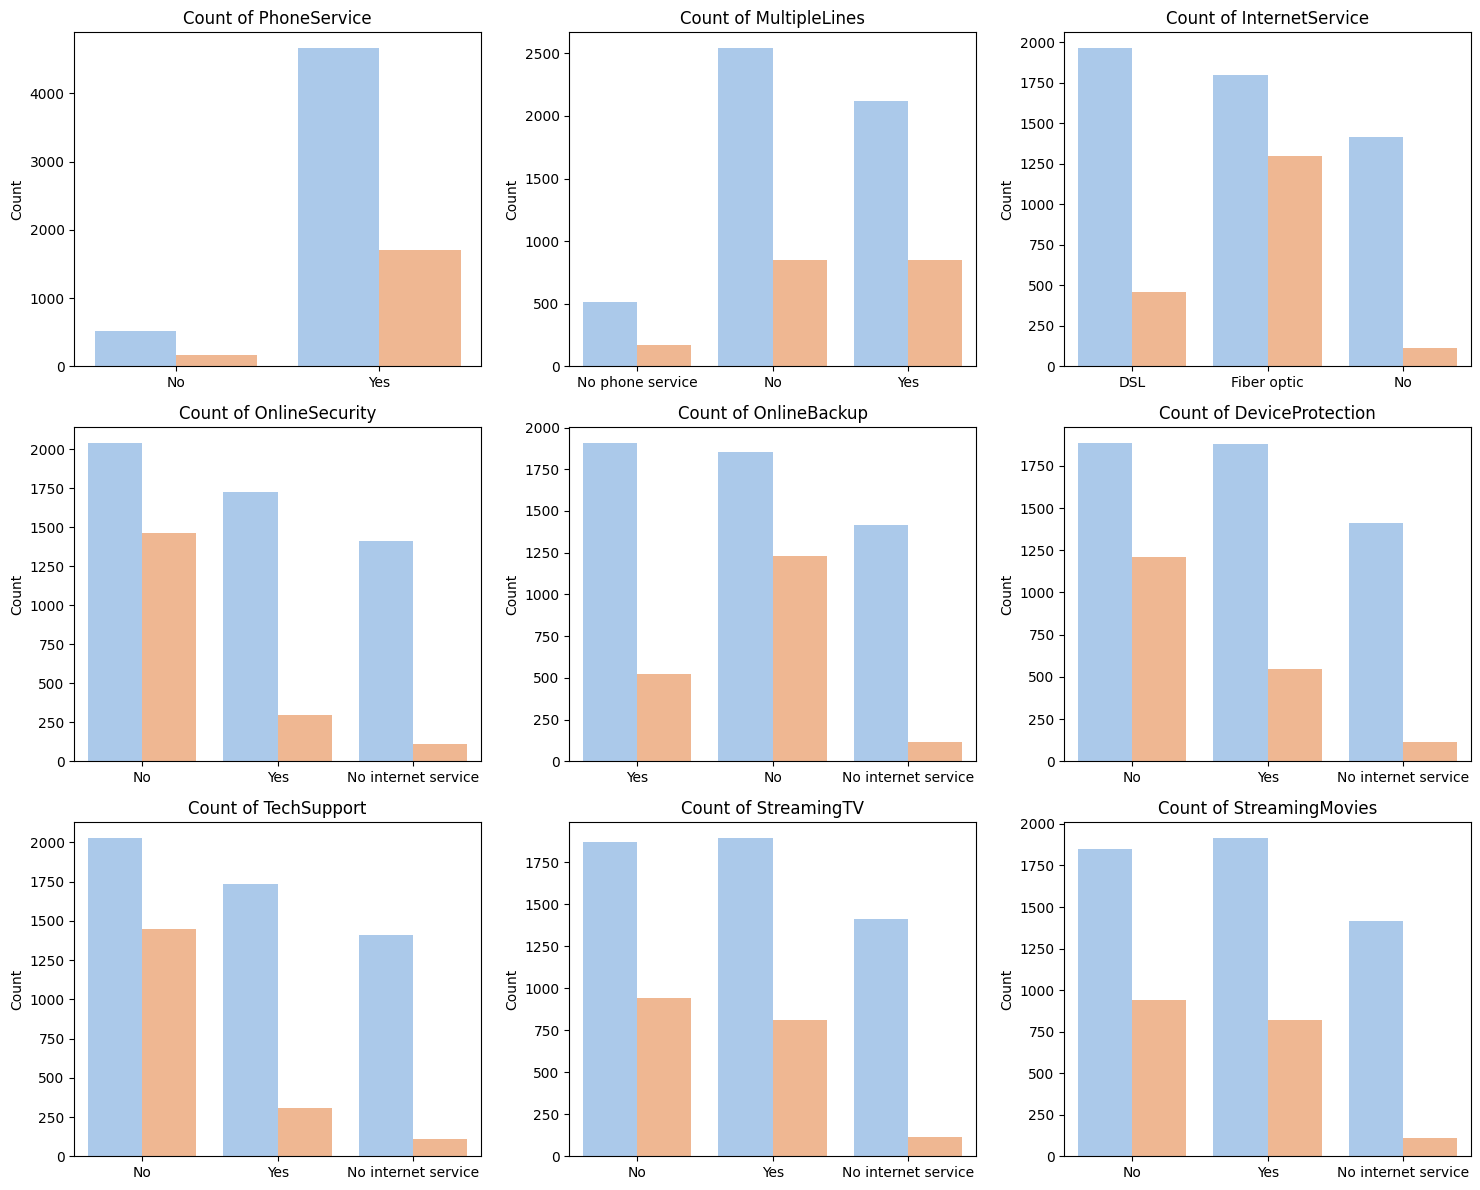

In [7]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, hue=df["Churn"], palette="pastel", legend=False, ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# remove empty subplot(s) if any
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Most customers have PhoneService, but a significant portion with it still churn.
Services like OnlineSecurity, TechSupport, and DeviceProtection show that churn is higher among customers who opted for "No".
Customers with Fiber optic Internet tend to churn more compared to DSL users.
Streaming services (TV/Movies) don’t strongly prevent churn; both "Yes" and "No" categories show notable churn counts.
    
=> Overall, lack of security/tech-support services and Fiber optic plans appear linked to higher churn.

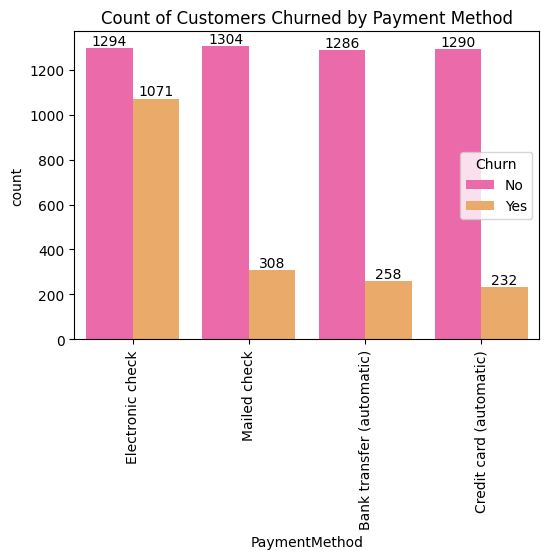

In [12]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "PaymentMethod", data = df,palette = "spring",hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xticks(rotation = 90)
plt.title("Count of Customers Churned by Payment Method")
plt.show()


Customers paying through Electronic Checks show the highest churn, highlighting the risk with flexible payment methods.
Mailed Checks have moderate churn, while automatic payments (Credit Card/Bank Transfer) show the lowest churn.
This indicates that encouraging customers to shift towards auto-pay options could help reduce churn significantly.

In [1]:
import matplotlib.pyplot as plt

# Group by PaymentMethod and Churn
payment_churn = df.groupby(["PaymentMethod", "Churn"]).size().reset_index(name="Count")

# Plot pie chart for each churn status
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, status in enumerate(payment_churn["Churn"].unique()):
    data = payment_churn[payment_churn["Churn"] == status]
    axes[i].pie(
        data["Count"], 
        labels=data["PaymentMethod"], 
        autopct="%1.1f%%", 
        startangle=90
       
    )
    axes[i].set_title(f"Payment Method Distribution - Churn = {status}")

plt.tight_layout()
plt.show()


NameError: name 'df' is not defined